In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install timm peft scikit-learn matplotlib seaborn -q

Mounted at /content/drive


In [ ]:
import os, json, pickle, random
from pathlib import Path

SEED = 42

PROJECT_DIR = Path("/content/drive/MyDrive/Indian_Food_Research")
SPLITS_DIR  = PROJECT_DIR / "splits"
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR  = PROJECT_DIR / "models"
FIGURES_DIR = PROJECT_DIR / "figures"

for d in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR, "| exists:", PROJECT_DIR.exists())


PROJECT_DIR: /content/drive/MyDrive/Indian_Food_Research | exists: True


In [ ]:
train_idx = pickle.load(open(SPLITS_DIR / "train_idx.pkl", "rb"))
val_idx   = pickle.load(open(SPLITS_DIR / "val_idx.pkl",   "rb"))
test_idx  = pickle.load(open(SPLITS_DIR / "test_idx.pkl",  "rb"))

print(f"Train: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}")
assert len(set(train_idx) & set(test_idx)) == 0, "Train/test overlap!"
assert len(set(val_idx)   & set(test_idx)) == 0, "Val/test overlap!"
print("Split integrity check passed.")

Train: 3204  Val: 687  Test: 687
Split integrity check passed.


In [ ]:
import torch, numpy as np
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

torch.manual_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

DATASET_PATH = PROJECT_DIR / "datasets" / "CompressedDataset"
full_ds      = datasets.ImageFolder(DATASET_PATH)
class_names  = full_ds.classes
num_classes  = len(class_names)
print(f"Classes: {num_classes}  Total images: {len(full_ds)}")

train_labels_for_idx = [full_ds.targets[i] for i in train_idx]

class TransformedSubset(Dataset):
    def __init__(self, base_ds, indices, transform):
        self.base_ds   = base_ds
        self.indices   = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        path, label = self.base_ds.samples[self.indices[i]]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label

def get_label_fraction_indices(indices, labels, fraction, seed=SEED):
    if fraction >= 1.0:
        return indices
    rng = random.Random(seed)
    by_class = {}
    for idx, lbl in zip(indices, labels):
        by_class.setdefault(lbl, []).append(idx)
    selected = []
    for lbl, idx_list in by_class.items():
        n = max(1, round(fraction * len(idx_list)))
        n = min(n, len(idx_list))
        shuffled = idx_list[:]
        rng.shuffle(shuffled)
        selected.extend(shuffled[:n])
    rng.shuffle(selected)
    return selected


Classes: 100  Total images: 4578


In [ ]:
import torch.nn as nn
import torch.optim as optim
import torchvision.models as tvm
import timm
from peft import LoraConfig, get_peft_model

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

def build_dinov2_lora(num_classes, r=8, alpha=16, target_modules=['qkv'], dropout=0.1):
    backbone = timm.create_model('vit_base_patch14_dinov2', pretrained=True,
                                  num_classes=num_classes, img_size=224)
    config = LoraConfig(r=r, lora_alpha=alpha, target_modules=target_modules,
                        lora_dropout=dropout, modules_to_save=["head"])
    model = get_peft_model(backbone, config)
    for n, p in model.named_parameters():
        if 'head' in n or 'classifier' in n:
            p.requires_grad = True
    return model

def build_dinov2_full_ft(num_classes):
    model = timm.create_model('vit_base_patch14_dinov2', pretrained=True,
                               num_classes=num_classes, img_size=224)
    for p in model.parameters():
        p.requires_grad = True
    return model

def build_dinov2_linear_probe(num_classes):
    model = timm.create_model('vit_base_patch14_dinov2', pretrained=True,
                               num_classes=num_classes, img_size=224)
    for n, p in model.named_parameters():
        if 'head' not in n:
            p.requires_grad = False
    return model

def build_resnet50_scratch(num_classes):
    model = tvm.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return trainable, total

Device: cuda


In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, weight_decay=1e-4):
    model = model.to(DEVICE)
    optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad],
                             lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE == 'cuda'))
    best_val_acc, best_state = 0.0, None

    for epoch in range(epochs):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):
                loss = criterion(model(imgs), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        scheduler.step()
        val_acc = evaluate_model(model, val_loader)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    epoch {epoch+1}/{epochs}  val_acc={val_acc:.4f}')

    if best_state:
        model.load_state_dict(best_state)
    return model, best_val_acc

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return correct / total


In [ ]:
val_loader  = DataLoader(TransformedSubset(full_ds, val_idx,  eval_tf),
                         batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(TransformedSubset(full_ds, test_idx, eval_tf),
                         batch_size=32, shuffle=False, num_workers=2)


In [ ]:
!pip install -q --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 106.7 MB/s eta 0:00:00


In [ ]:
import shutil
from pathlib import Path

LOCAL_DS = Path("/content/indian_food_cached")

# Remove the incomplete copy
if LOCAL_DS.exists():
    print("Removing incomplete local copy...")
    shutil.rmtree(str(LOCAL_DS))
    print("Removed.")

ORIGINAL_DS = Path("/content/drive/MyDrive/Indian_Food_Research/datasets/CompressedDataset")

print("Copying dataset locally (fresh)...")
shutil.copytree(str(ORIGINAL_DS), str(LOCAL_DS))
print("Done.")

# Verify counts match
orig_count = sum(1 for _ in ORIGINAL_DS.rglob('*') if _.is_file())
local_count = sum(1 for _ in LOCAL_DS.rglob('*') if _.is_file())
print(f"Original: {orig_count} files | Local copy: {local_count} files")
assert orig_count == local_count, "MISMATCH — copy is still incomplete!"
print("Copy verified complete ✓")

Removing incomplete local copy...
Removed.
Copying dataset locally (fresh)...
Done.
Original: 4578 files | Local copy: 4578 files
Copy verified complete ✓


In [ ]:
print("full_ds samples:", len(full_ds.samples))
print("full_ds classes:", len(full_ds.classes))

for name, idx in [("train_idx", train_idx), ("val_idx", val_idx), ("test_idx", test_idx)]:
    print(name, "count:", len(idx), "max:", max(idx), "min:", min(idx))

full_ds samples: 3309
full_ds classes: 74
train_idx count: 3204 max: 4577 min: 0
val_idx count: 687 max: 4572 min: 2
test_idx count: 687 max: 4570 min: 3


In [ ]:
class_folders = sorted([p for p in ORIGINAL_DS.iterdir() if p.is_dir()])
print("Class folders found:", len(class_folders))
print(class_folders[:100])

# Check for any files sitting directly in CompressedDataset
stray_files = [p for p in ORIGINAL_DS.iterdir() if p.is_file()]
print("Stray files at top level:", len(stray_files), stray_files[:10])

# Per-class file counts
for cf in class_folders:
    n = sum(1 for _ in cf.rglob('*') if _.is_file())
    print(f"{cf.name}: {n}")

Class folders found: 100
[PosixPath('/content/drive/MyDrive/Indian_Food_Research/datasets/CompressedDataset/Aalubhat'), PosixPath('/content/drive/MyDrive/Indian_Food_Research/datasets/CompressedDataset/Alfredo_Pasta'), PosixPath('/content/drive/MyDrive/Indian_Food_Research/datasets/CompressedDataset/Aloo_Paratha'), PosixPath('/content/drive/MyDrive/Indian_Food_Research/datasets/CompressedDataset/Aloo_sabji'), PosixPath('/content/drive/MyDrive/Indian_Food_Research/datasets/CompressedDataset/Alu_vadi'), PosixPath('/content/drive/MyDrive/Indian_Food_Research/datasets/CompressedDataset/Appam'), PosixPath('/content/drive/MyDrive/Indian_Food_Research/datasets/CompressedDataset/Basundi'), PosixPath('/content/drive/MyDrive/Indian_Food_Research/datasets/CompressedDataset/Bhakri_thecha'), PosixPath('/content/drive/MyDrive/Indian_Food_Research/datasets/CompressedDataset/Bhindi_Sabji'), PosixPath('/content/drive/MyDrive/Indian_Food_Research/datasets/CompressedDataset/Bombay_Halwa'), PosixPath('/co

In [ ]:
from torchvision import datasets

check_orig = datasets.ImageFolder(str(DATASET_PATH))
print("ORIGINAL (Drive) -> classes:", len(check_orig.classes), "| samples:", len(check_orig.samples))

# Rebuild explicitly from the LOCAL copy
check_local = datasets.ImageFolder(str(LOCAL_DS))
print("LOCAL copy        -> classes:", len(check_local.classes), "| samples:", len(check_local.samples))

missing = set(check_orig.classes) - set(check_local.classes)
extra   = set(check_local.classes) - set(check_orig.classes)
print("Classes in Drive but missing locally:", sorted(missing))
print("Classes in local but not in Drive (unexpected):", sorted(extra))

ORIGINAL (Drive) -> classes: 100 | samples: 4578
LOCAL copy        -> classes: 100 | samples: 4578
Classes in Drive but missing locally: []
Classes in local but not in Drive (unexpected): []


In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

full_ds = datasets.ImageFolder(str(LOCAL_DS))
class_names = full_ds.classes
num_classes = len(class_names)
print("full_ds rebuilt -> classes:", num_classes, "| samples:", len(full_ds.samples))

assert max(train_idx) < len(full_ds.samples), "train_idx still out of range!"
assert max(val_idx)   < len(full_ds.samples), "val_idx still out of range!"
assert max(test_idx)  < len(full_ds.samples), "test_idx still out of range!"
print("Split indices verified in range ✓")

train_labels_for_idx = [full_ds.targets[i] for i in train_idx]

val_loader  = DataLoader(TransformedSubset(full_ds, val_idx,  eval_tf),
                         batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(TransformedSubset(full_ds, test_idx, eval_tf),
                         batch_size=32, shuffle=False, num_workers=2)

print("full_ds, train_labels_for_idx, val_loader, test_loader all rebuilt.")

full_ds rebuilt -> classes: 100 | samples: 4578
Split indices verified in range ✓
full_ds, train_labels_for_idx, val_loader, test_loader all rebuilt.


In [ ]:
FRACTIONS = [0.10, 0.25, 0.50, 1.00]
METHODS   = ['resnet50_scratch', 'linear_probe', 'lora', 'full_finetune']
EPOCHS    = {'resnet50_scratch': 15, 'linear_probe': 10, 'lora': 10, 'full_finetune': 8}
LR        = {'resnet50_scratch': 1e-3, 'linear_probe': 1e-3, 'lora': 1e-3, 'full_finetune': 1e-5}

CKPT_PATH = str(RESULTS_DIR / 'label_efficiency_checkpoints.json')

if os.path.exists(CKPT_PATH):
    with open(CKPT_PATH) as f:
        results = json.load(f)
    done_keys = {(r['method'], r['fraction']) for r in results}
    print(f"Resuming — {len(done_keys)}/16 combos already done: {done_keys}")
else:
    results, done_keys = [], set()

before = len(results)
results = [r for r in results if not (r['method'] == 'lora' and r['fraction'] == 1.0)]
after = len(results)
print(f"Removed {before - after} stale entries")

done_keys = {(r['method'], r['fraction']) for r in results}
print(f"done_keys now has {len(done_keys)} entries")

with open(CKPT_PATH, 'w') as f:
    json.dump(results, f, indent=2)


for fraction in FRACTIONS:
    sub_train_idx = get_label_fraction_indices(train_idx, train_labels_for_idx, fraction)
    sub_train_ds  = TransformedSubset(full_ds, sub_train_idx, train_tf)
    train_loader  = DataLoader(sub_train_ds, batch_size=32, shuffle=True, num_workers=2)

    for method in METHODS:
        key = (method, fraction)
        if key in done_keys:
            print(f"SKIP (done): {method} @ {int(fraction*100)}%")
            continue

        print(f'\n=== {method} | {int(fraction*100)}% labels | n={len(sub_train_idx)} ===')

        if method == 'resnet50_scratch':
            model = build_resnet50_scratch(num_classes)
        elif method == 'linear_probe':
            model = build_dinov2_linear_probe(num_classes)
        elif method == 'lora':
            model = build_dinov2_lora(num_classes, r=8, target_modules=['qkv'])
        elif method == 'full_finetune':
            model = build_dinov2_full_ft(num_classes)

        trainable, total = count_trainable_params(model)
        model, best_val_acc = train_model(model, train_loader, val_loader,
                                          epochs=EPOCHS[method], lr=LR[method])
        test_acc = evaluate_model(model, test_loader)

        print(f'  params: {trainable:,}/{total:,} ({100*trainable/total:.3f}%)')
        print(f'  test_acc: {test_acc:.4f}')

        # Save model checkpoint at 100%
        if fraction == 1.0:
            if method == 'lora':
                save_path = str(MODELS_DIR / 'dinov2_lora_full.pth')
                torch.save(model.state_dict(), save_path)
                print(f"  Full LoRA model (adapter + head) saved to {save_path}")
            else:
                torch.save(model.state_dict(), str(MODELS_DIR / f'{method}_100pct.pt'))
            print(f'  Model saved to {MODELS_DIR}')

        results.append({
            'method': method, 'fraction': fraction,
            'pct_labels': int(fraction * 100),
            'n_train_images': len(sub_train_idx),
            'trainable_params': trainable, 'total_params': total,
            'trainable_pct': 100 * trainable / total,
            'val_acc': float(best_val_acc), 'test_acc': float(test_acc)
        })

        # Checkpoint after every single run
        with open(CKPT_PATH, 'w') as f:
            json.dump(results, f, indent=2)
        done_keys.add(key)
        print(f'  Checkpoint saved ({len(results)}/16 done)')

        del model
        torch.cuda.empty_cache()

import pandas as pd
results_df = pd.DataFrame(results)
csv_path = str(RESULTS_DIR / 'label_efficiency_results.csv')
results_df.to_csv(csv_path, index=False)
print(f'\nFinal CSV saved: {csv_path}')
results_df

Resuming — 15/16 combos already done: {('full_finetune', 1.0), ('lora', 0.1), ('resnet50_scratch', 1.0), ('linear_probe', 0.1), ('lora', 0.5), ('resnet50_scratch', 0.25), ('resnet50_scratch', 0.5), ('full_finetune', 0.25), ('full_finetune', 0.5), ('linear_probe', 1.0), ('resnet50_scratch', 0.1), ('full_finetune', 0.1), ('lora', 0.25), ('linear_probe', 0.5), ('linear_probe', 0.25)}
Removed 0 stale entries
done_keys now has 15 entries
SKIP (done): resnet50_scratch @ 10%
SKIP (done): linear_probe @ 10%
SKIP (done): lora @ 10%
SKIP (done): full_finetune @ 10%
SKIP (done): resnet50_scratch @ 25%
SKIP (done): linear_probe @ 25%
SKIP (done): lora @ 25%
SKIP (done): full_finetune @ 25%
SKIP (done): resnet50_scratch @ 50%
SKIP (done): linear_probe @ 50%
SKIP (done): lora @ 50%
SKIP (done): full_finetune @ 50%
SKIP (done): resnet50_scratch @ 100%
SKIP (done): linear_probe @ 100%

=== lora | 100% labels | n=3204 ===


/tmp/ipykernel_502/3707680094.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE == 'cuda'))
/tmp/ipykernel_502/3707680094.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):


    epoch 1/10  val_acc=0.9243
    epoch 2/10  val_acc=0.9389
    epoch 3/10  val_acc=0.9491
    epoch 4/10  val_acc=0.9549
    epoch 5/10  val_acc=0.9549
    epoch 6/10  val_acc=0.9549
    epoch 7/10  val_acc=0.9578
    epoch 8/10  val_acc=0.9592
    epoch 9/10  val_acc=0.9592
    epoch 10/10  val_acc=0.9592
  params: 448,712/86,173,640 (0.521%)
  test_acc: 0.9592
  Full LoRA model (adapter + head) saved to /content/drive/MyDrive/Indian_Food_Research/models/dinov2_lora_full.pth
  Model saved to /content/drive/MyDrive/Indian_Food_Research/models
  Checkpoint saved (16/16 done)
SKIP (done): full_finetune @ 100%

Final CSV saved: /content/drive/MyDrive/Indian_Food_Research/results/label_efficiency_results.csv


,method,fraction,pct_labels,n_train_images,trainable_params,total_params,trainable_pct,val_acc,test_acc
0,resnet50_scratch,0.10,10,327,23712932,23712932,100.000000,0.088792,0.104803
1,linear_probe,0.10,10,327,76900,85801828,0.089625,0.807860,0.788937
2,lora,0.10,10,327,371812,86096740,0.431854,0.835517,0.802038
3,full_finetune,0.10,10,327,85801828,85801828,100.000000,0.665211,0.647744
4,resnet50_scratch,0.25,25,798,23712932,23712932,100.000000,0.286754,0.260553
5,linear_probe,0.25,25,798,76900,85801828,0.089625,0.899563,0.882096
6,lora,0.25,25,798,371812,86096740,0.431854,0.918486,0.889374
7,full_finetune,0.25,25,798,85801828,85801828,100.000000,0.855895,0.836972
8,resnet50_scratch,0.50,50,1600,23712932,23712932,100.000000,0.481805,0.481805
9,linear_probe,0.50,50,1600,76900,85801828,0.089625,0.928675,0.924309


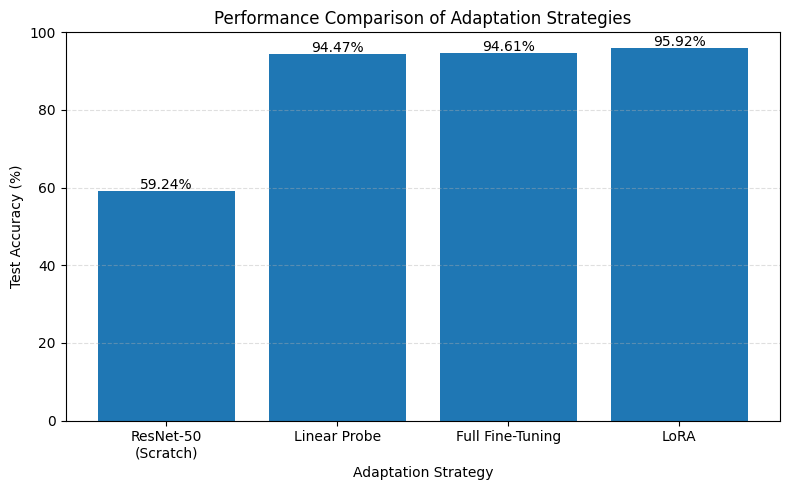

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV
df = pd.read_csv(RESULTS_DIR / "label_efficiency_results.csv")

# Use only 100% training data
df = df[df["fraction"] == 1.0].copy()

# Display names
name_map = {
    "resnet50_scratch": "ResNet-50\n(Scratch)",
    "linear_probe": "Linear Probe",
    "lora": "LoRA",
    "full_finetune": "Full Fine-Tuning"
}

df["Model"] = df["method"].map(name_map)

plt.figure(figsize=(8,5))

bars = plt.bar(
    df["Model"],
    df["test_acc"] * 100
)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.5,
        f"{h:.2f}%",
        ha="center",
        fontsize=10
    )

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Adaptation Strategy")
plt.title("Performance Comparison of Adaptation Strategies")

plt.ylim(0,100)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "performance_comparison_adaptation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

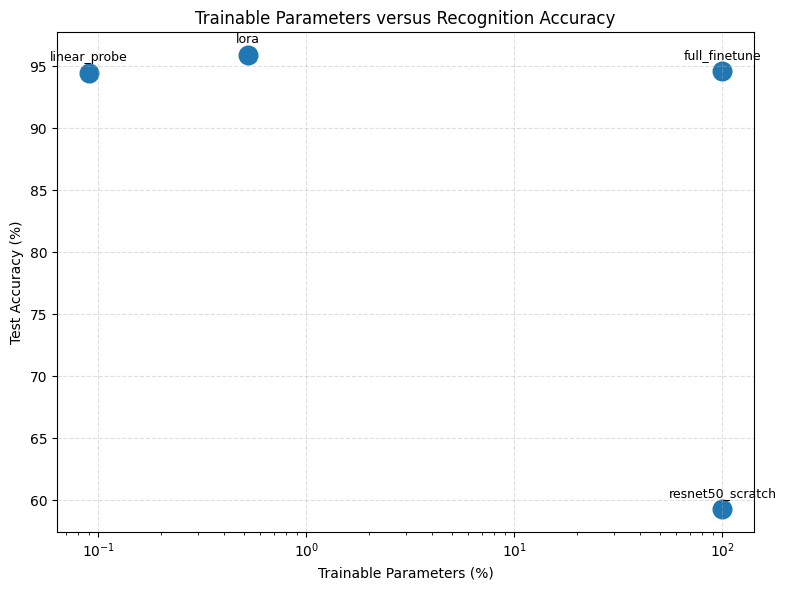

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv(RESULTS_DIR / "label_efficiency_results.csv")

# Use only 100% training data
df = df[df["fraction"] == 1.0]

plt.figure(figsize=(8,6))

plt.scatter(
    df["trainable_pct"],
    df["test_acc"] * 100,
    s=180
)

for _, row in df.iterrows():
    plt.text(
        row["trainable_pct"],
        row["test_acc"] * 100 + 1,
        row["method"],
        ha="center",
        fontsize=9
    )

plt.xscale("log")

plt.xlabel("Trainable Parameters (%)")
plt.ylabel("Test Accuracy (%)")
plt.title("Trainable Parameters versus Recognition Accuracy")

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "trainable_parameters_vs_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

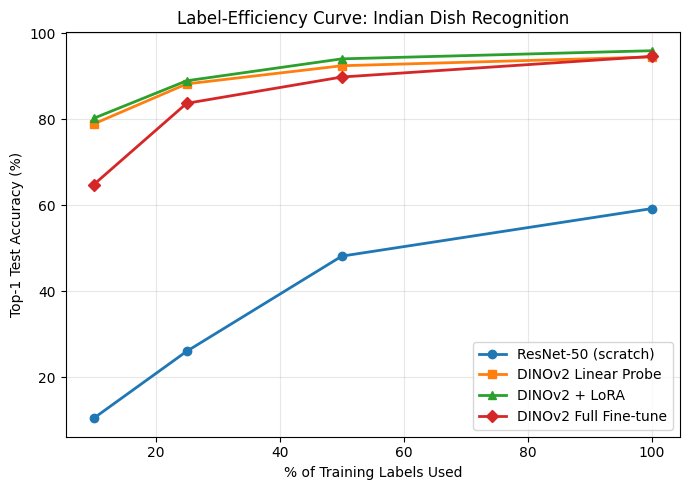

Saved Figure 5: /content/drive/MyDrive/Indian_Food_Research/figures/label_efficiency_curve.pdf


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

results_df = pd.read_csv(str(RESULTS_DIR / 'label_efficiency_results.csv'))

method_labels = {
    'resnet50_scratch': 'ResNet-50 (scratch)',
    'linear_probe':     'DINOv2 Linear Probe',
    'lora':             'DINOv2 + LoRA',
    'full_finetune':    'DINOv2 Full Fine-tune'
}
markers = {'resnet50_scratch': 'o', 'linear_probe': 's', 'lora': '^', 'full_finetune': 'D'}
METHODS = ['resnet50_scratch', 'linear_probe', 'lora', 'full_finetune']

plt.figure(figsize=(7, 5))
for method in METHODS:
    sub = results_df[results_df['method'] == method].sort_values('pct_labels')
    plt.plot(sub['pct_labels'], sub['test_acc'] * 100,
             marker=markers[method], label=method_labels[method], linewidth=2)

plt.xlabel('% of Training Labels Used')
plt.ylabel('Top-1 Test Accuracy (%)')
plt.title('Label-Efficiency Curve: Indian Dish Recognition')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

fig5_path = str(FIGURES_DIR / 'label_efficiency_curve.pdf')
plt.savefig(fig5_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved Figure 5: {fig5_path}')
